In [3]:
import pandas as pd
import pickle
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [34]:
final_gen = pd.read_csv('../key_files/final_gen.csv')['sample_name'].to_list()
delta_ef=pd.read_csv('../key_files/delta_ecotype_freq.txt', sep = '\t', usecols = final_gen)#[['log_p1_p0','ecotype', 'site','plot']]

In [16]:
file_path = '../jacknife_lfmm/splits_samples.pkl'

# Open and load the .pkl file
with open(file_path, 'rb') as file:
    samples = pickle.load(file)

In [41]:
genotype_counts = pd.read_csv('../leave_1_out/genotype_counts_fullgenome231ecotypes.csv').drop('Unnamed: 0', axis=1)

In [44]:
snp_dict = pd.read_csv('../key_files/var_pos_grenenet.csv')

In [38]:
train = samples[0][0]
test = samples[0][1]

In [5]:
br_results = pd.read_csv('binomial_reg_results_last_gen.csv')

In [9]:
br_results = br_results[br_results['pvalue'] < 0.05/len(br_results)]

In [11]:
br_results['intercept'] = 0

/tmp/ipykernel_619349/2518937414.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  br_results['intercept'] = 0


In [23]:
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_experimental_sites_era5.csv')

In [27]:
sites_test = pd.Series(test).str.split('_').str[0].astype(int)

#sites_test.name = 'site'

#env = sites_test.reset_index().merge(clim_sites_during_exp).drop(['index'],axis=1)

In [30]:
sites_test.unique()[0]

1

In [37]:
test_bio1 = clim_sites_during_exp[clim_sites_during_exp['site'] == sites_test.unique()[0]]['bio1'][0]

In [ ]:
## prediciotn of allele freq in that location 

In [39]:
br_results['predicted_af'] = test_bio1 * br_results['slope'] + br_results['intercept']

/tmp/ipykernel_619349/10072152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  br_results['predicted_af'] = test_bio1 * br_results['slope'] + br_results['intercept']


In [49]:
mask_full_genotype = snp_dict['id'].isin(br_results['snp_id'])

In [51]:
mask_full_genotype

0          False
1          False
2          False
3          False
4          False
           ...  
3235475    False
3235476    False
3235477    False
3235478     True
3235479     True
Name: id, Length: 3235480, dtype: bool

In [40]:
br_results

,slope,pvalue,snp_id,intercept,predicted_af
3,0.588284,2.536460e-138,1_395,0,6.320472
4,0.588284,2.536460e-138,1_396,0,6.320472
7,0.657404,8.407327e-177,1_465,0,7.063083
10,0.211540,3.819442e-37,1_508,0,2.272766
11,0.372599,6.959796e-73,1_643,0,4.003173
...,...,...,...,...,...
1048625,-0.219671,1.329228e-17,5_26974485,0,-2.360126
1048629,-0.194857,1.249174e-39,5_26975046,0,-2.093525
1048630,-0.291705,1.978042e-74,5_26975078,0,-3.134046
1048633,0.085222,5.859110e-12,5_26975272,0,0.915620


In [53]:
genotype_counts = genotype_counts.loc[mask_full_genotype,:]

<Axes: xlabel='predicted_af', ylabel='Count'>

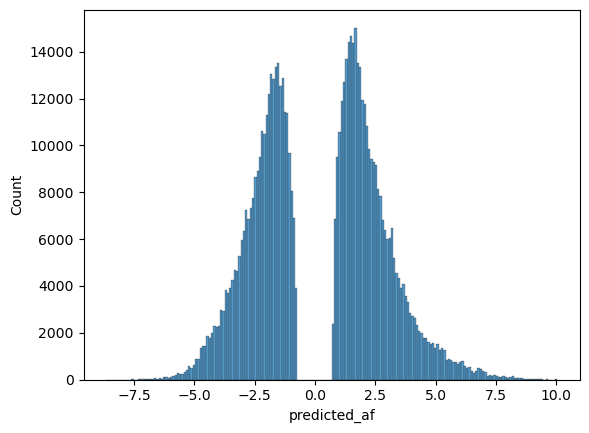

In [56]:
sns.histplot(br_results['predicted_af'])

In [54]:
genotype_counts

,0,1,2,3,4,5,6,7,8,9,...,221,222,223,224,225,226,227,228,229,230
6,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
7,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,2
15,2,2,2,2,2,0,2,0,2,0,...,2,0,0,2,2,2,2,2,0,2
27,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3235438,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3235464,2,2,2,2,2,2,2,2,2,2,...,0,2,2,0,2,2,2,2,2,2
3235468,2,2,2,2,2,2,2,2,2,2,...,0,2,2,0,2,2,2,2,2,2
3235478,2,0,0,2,2,2,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0


In [ ]:
genomic_offset = np.sum(sample_coefficients * genotype_counts_array, axis=0)
            pos_genomic_offsets[sample] = genomic_offset